<a href="https://colab.research.google.com/github/Nischalh777/Capstone_Project_ISE_6-/blob/main/Train-Resnet-50-PlantDisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 #==============================================================================
# Part 1: Setup - Install, Authenticate, and Prepare Dataset Paths
# ==============================================================================
# This version has a more robust method to find the correct data directory.

# Step 1: Install necessary libraries
!pip install kaggle kagglehub -q


In [ ]:
# Step 2: Import libraries and prompt for Kaggle API key
from google.colab import files
import os
import kagglehub
import zipfile

print("Please upload your kaggle.json file from your Kaggle account page.")
uploaded = files.upload()

# Step 3: Configure Kaggle API
if 'kaggle.json' in uploaded:
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("\n✅ Kaggle API configured successfully.")
else:
    raise ValueError("\n🔴 kaggle.json not found. Please re-run the cell and upload the file.")

# Step 4: Access the Dataset via KaggleHub
DATASET_SLUG = "abdallahalidev/plantvillage-dataset"
print(f"\n--- Accessing dataset: '{DATASET_SLUG}' ---")
try:
    dataset_dir = kagglehub.dataset_download(DATASET_SLUG)
    print(f"✅ Dataset is available in root directory: {dataset_dir}")

    # Step 5: Construct the explicit path to the 'color' directory
    # This is the most reliable method based on the known dataset structure.
    data_root = os.path.join(dataset_dir, "plantvillage dataset", "color")

    if not os.path.exists(data_root):
        # Fallback for a different common structure, just in case
        data_root_fallback = os.path.join(dataset_dir, "color")
        if os.path.exists(data_root_fallback):
            data_root = data_root_fallback
        else:
             raise FileNotFoundError(f"Could not find the image data directory at '{data_root}' or other common locations.")

    print(f"✅ Found data source at: {data_root}")

except Exception as e:
    raise RuntimeError(f"🔴 An error occurred during dataset access: {e}")


Please upload your kaggle.json file from your Kaggle account page.


Saving kaggle.json to kaggle.json

✅ Kaggle API configured successfully.

--- Accessing dataset: 'abdallahalidev/plantvillage-dataset' ---
✅ Dataset is available in root directory: /kaggle/input/plantvillage-dataset
✅ Found data source at: /kaggle/input/plantvillage-dataset/plantvillage dataset/color


In [ ]:
# ==============================================================================
# Part 2: Data Preparation - Transforms, Splitting, and DataLoaders
# ==============================================================================
# All necessary imports are included here to prevent NameError.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torchvision import transforms  # <--- THIS IS THE MISSING IMPORT
from torchvision.models import resnet50, ResNet50_Weights
import json

# Set device to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n--- Data Preparation ---")
print(f"Using device: {device}")

# Define image transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create a full dataset object
full_dataset = ImageFolder(data_root, transform=None)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"✅ Found {num_classes} classes.")

# Split the dataset
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(full_dataset, [train_size, val_size], generator=generator)

# Apply the correct transforms
class TransformedDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        return self.transform(x), y
    def __len__(self):
        return len(self.subset)

train_dataset = TransformedDataset(train_subset, train_transform)
val_dataset = TransformedDataset(val_subset, val_transform)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

# Create DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("✅ DataLoaders created successfully.")



--- Data Preparation ---
Using device: cuda
✅ Found 38 classes.
Training set size: 43444
Validation set size: 10861
✅ DataLoaders created successfully.


In [ ]:
# ==============================================================================
# Part 3: Model Definition and Training Loop
# ==============================================================================

model = resnet50(weights=ResNet50_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)
model = model.to(device)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

epochs = 10
train_accuracies, val_accuracies = [], []

print("\n--- Starting Model Training ---")
for epoch in range(epochs):
    # Training Phase...
    model.train()
    total_train_correct = 0
    total_train_samples = 0
    for data, targets in train_loader:
        data, targets = data.to(device), targets.to(device)
        scores = model(data)
        loss = criterion(scores, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        _, predictions = scores.max(1)
        total_train_correct += (predictions == targets).sum().item()
        total_train_samples += data.size(0)
    avg_train_acc = (total_train_correct / total_train_samples) * 100
    train_accuracies.append(avg_train_acc)

    # Validation Phase...
    model.eval()
    total_val_correct = 0
    total_val_samples = 0
    with torch.no_grad():
        for data, targets in val_loader:
            data, targets = data.to(device), targets.to(device)
            scores = model(data)
            _, predictions = scores.max(1)
            total_val_correct += (predictions == targets).sum().item()
            total_val_samples += data.size(0)
    avg_val_acc = (total_val_correct / total_val_samples) * 100
    val_accuracies.append(avg_val_acc)

    print(f'Epoch {epoch+1}/{epochs} | Train Acc: {avg_train_acc:.2f}% | Val Acc: {avg_val_acc:.2f}%')

print("\n--- Training Complete ---")



--- Starting Model Training ---
Epoch 1/10 | Train Acc: 85.32% | Val Acc: 91.47%
Epoch 2/10 | Train Acc: 94.93% | Val Acc: 93.40%
Epoch 3/10 | Train Acc: 96.05% | Val Acc: 94.27%
Epoch 4/10 | Train Acc: 96.77% | Val Acc: 94.87%
Epoch 5/10 | Train Acc: 97.08% | Val Acc: 95.59%
Epoch 6/10 | Train Acc: 97.39% | Val Acc: 95.53%
Epoch 7/10 | Train Acc: 97.54% | Val Acc: 95.69%
Epoch 8/10 | Train Acc: 97.78% | Val Acc: 95.77%
Epoch 9/10 | Train Acc: 97.90% | Val Acc: 95.81%
Epoch 10/10 | Train Acc: 97.94% | Val Acc: 95.88%

--- Training Complete ---


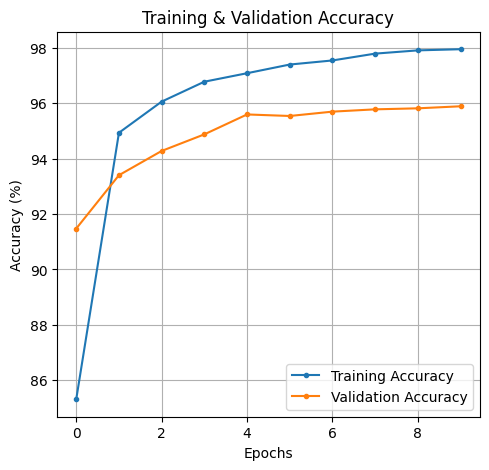


--- Final Evaluation Report (on Validation Set) ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.98      0.98       130
                                 Apple___Black_rot       0.99      1.00      1.00       120
                          Apple___Cedar_apple_rust       1.00      0.88      0.93        49
                                   Apple___healthy       1.00      0.96      0.98       359
                               Blueberry___healthy       0.98      1.00      0.99       290
          Cherry_(including_sour)___Powdery_mildew       1.00      0.98      0.99       249
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       166
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.78      0.84        86
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       225
               Corn_(maize

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==============================================================================
# Part 4 & 5: Evaluation and Saving
# ==============================================================================

# --- Plotting training history ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Training Accuracy', marker='.')
plt.plot(val_accuracies, label='Validation Accuracy', marker='.')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# --- Classification Report ---
print("\n--- Final Evaluation Report (on Validation Set) ---")
model.eval()
all_predictions = []
all_targets = []
with torch.no_grad():
    for data, targets in val_loader:
        data, targets = data.to(device), targets.to(device)
        scores = model(data)
        _, predictions = scores.max(1)
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
print(classification_report(all_targets, all_predictions, target_names=class_names, zero_division=0))

# --- Save and Download Files ---
model_save_path = "plant_disease_model.pth"
class_names_path = "class_names.json"
torch.save(model.state_dict(), model_save_path)
print(f"\n✅ Model successfully saved to '{model_save_path}'")
with open(class_names_path, 'w') as f:
    json.dump(class_names, f)
print(f"✅ Class names successfully saved to '{class_names_path}'")
print("\n--- Downloading files to your local machine... ---")
files.download(model_save_path)
files.download(class_names_path)